Modelagem de teste

In [2]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../data/demanda_supermercado_2023_2024.csv")
df["data"] = pd.to_datetime(df["data"])
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia_semana"] = df["data"].dt.day_name()

In [4]:
# Seleção de features e target
features = ["produto", "categoria", "mes", "dia_semana", "preco_unitario"]
target = "quantidade_vendida"
X = df[features]
y = df[target]

In [5]:
# Separação temporal: treino (2023) e teste (2024)
X_train = X[df["ano"] == 2023]
X_test = X[df["ano"] == 2024]
y_train = y[df["ano"] == 2023]
y_test = y[df["ano"] == 2024]

In [6]:
# Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["produto", "categoria", "dia_semana"])
    ],
    remainder="passthrough"
)

# Pipeline regressão linear
pipeline_lr = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

In [7]:
# Pipeline random forest
pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

In [10]:
from sklearn.ensemble import RandomForestRegressor


In [14]:
# Treinar e avaliar regressão linear
pipeline_lr.fit(X_train, y_train)
pred_lr = pipeline_lr.predict(X_test)

# Calcular RMSE manualmente
mse = mean_squared_error(y_test, pred_lr)
rmse = round(np.sqrt(mse), 2)

# Métricas finais
metrics_lr = {
    "Modelo": "Regressão Linear",
    "RMSE": rmse,
    "MAE": round(mean_absolute_error(y_test, pred_lr), 2),
    "R²": round(r2_score(y_test, pred_lr), 4)
}


In [15]:
# Treinar e avaliar random forest
pipeline_rf.fit(X_train, y_train)
pred_rf = pipeline_rf.predict(X_test)

# Calcular RMSE manualmente
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = round(np.sqrt(mse_rf), 2)

# Métricas finais
metrics_rf = {
    "Modelo": "Random Forest Regressor",
    "RMSE": rmse_rf,
    "MAE": round(mean_absolute_error(y_test, pred_rf), 2),
    "R²": round(r2_score(y_test, pred_rf), 4)
}

# Visualizar os dois resultados juntos
metrics_lr, metrics_rf

({'Modelo': 'Regressão Linear',
  'RMSE': np.float64(47.03),
  'MAE': 38.75,
  'R²': 0.1206},
 {'Modelo': 'Random Forest Regressor',
  'RMSE': np.float64(51.74),
  'MAE': 41.92,
  'R²': -0.0645})

In [18]:
import pandas as pd

# Dados fornecidos
resultados_modelos = [
    {"Modelo": "Regressão Linear", "RMSE": 47.03, "MAE": 38.75, "R²": 0.1206},
    {"Modelo": "Random Forest Regressor", "RMSE": 51.74, "MAE": 41.92, "R²": -0.0645}
]

# Criar DataFrame
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados

,Modelo,RMSE,MAE,R²
0,Regressão Linear,47.03,38.75,0.1206
1,Random Forest Regressor,51.74,41.92,-0.0645


## GradientBoostingRegressor com OrdinalEncoder

In [19]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor

In [20]:
# Preparar pipeline com OrdinalEncoder
preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["produto", "categoria", "dia_semana"])
], remainder="passthrough")

pipeline_gbr = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

In [21]:
# Treinar modelo
pipeline_gbr.fit(X_train, y_train)

C:\Users\jessi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['produto', 'categoria',
                                                   'dia_semana'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [22]:
# Avaliar modelo
preds_gbr = pipeline_gbr.predict(X_test)
rmse = round(np.sqrt(mean_squared_error(y_test, preds_gbr)), 2)
mae = round(mean_absolute_error(y_test, preds_gbr), 2)
r2 = round(r2_score(y_test, preds_gbr), 4)

{
    "Modelo": "GradientBoosting com OrdinalEncoder",
    "RMSE": rmse,
    "MAE": mae,
    "R²": r2
}

{'Modelo': 'GradientBoosting com OrdinalEncoder',
 'RMSE': np.float64(46.43),
 'MAE': 38.44,
 'R²': 0.1427}

In [25]:
import pandas as pd

# Dados fornecidos
resultados_modelos = [
    {"Modelo": "Regressão Linear", "RMSE": 47.03, "MAE": 38.75, "R²": 0.1206},
    {"Modelo": "Random Forest Regressor", "RMSE": 51.74, "MAE": 41.92, "R²": -0.0645},
    {"Modelo": "GradientBoosting com OrdinalEncoder", "RMSE": 46.43, "MAE": 38.44, "R²": 0.1427}
]

# Criar DataFrame
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados

,Modelo,RMSE,MAE,R²
0,Regressão Linear,47.03,38.75,0.1206
1,Random Forest Regressor,51.74,41.92,-0.0645
2,GradientBoosting com OrdinalEncoder,46.43,38.44,0.1427


Importância das variáveis

In [32]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [33]:
# Calcular importância das variáveis via permutação
importancia = permutation_importance(
    pipeline_gbr, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

In [34]:
# Nome das variáveis após o encoder
encoded_columns = (
    pipeline_gbr.named_steps["preprocess"]
    .transformers_[0][2] + ["mes", "preco_unitario"]
)

In [35]:
# DataFrame com resultados
importancia_df = pd.DataFrame({
    "Variável": encoded_columns,
    "Importância Média": importancia.importances_mean,
    "Desvio": importancia.importances_std
}).sort_values(by="Importância Média", ascending=False)

importancia_df.reset_index(drop=True, inplace=True)
importancia_df.head(20)

,Variável,Importância Média,Desvio
0,mes,0.225542,0.006563
1,dia_semana,0.044234,0.003053
2,categoria,0.042759,0.003438
3,preco_unitario,0.005233,0.001320
4,produto,0.001862,0.000479


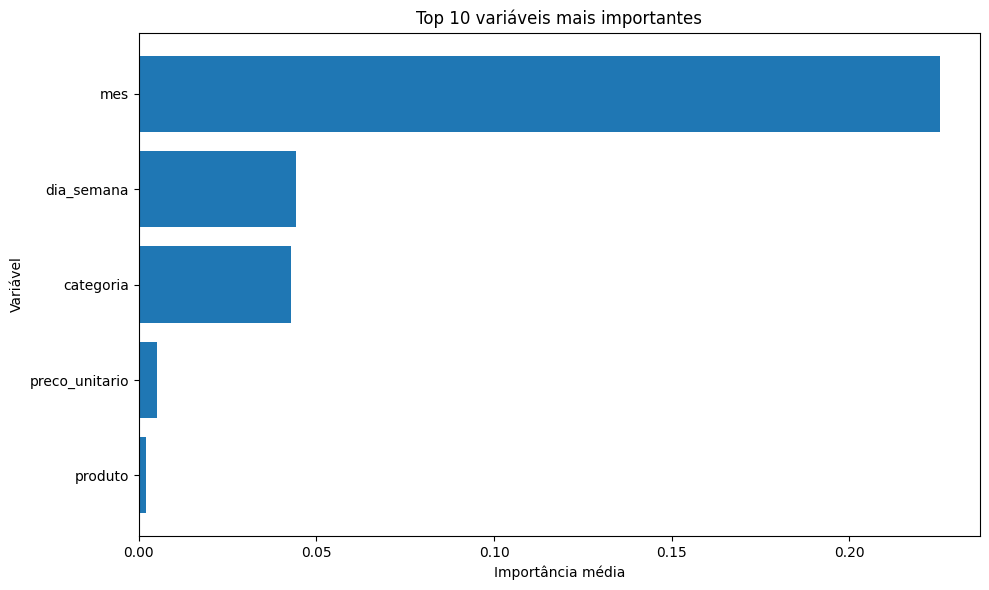

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(importancia_df["Variável"][:10], importancia_df["Importância Média"][:10])
plt.xlabel("Importância média")
plt.ylabel("Variável")
plt.title("Top 10 variáveis mais importantes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()